In [1]:
import torch 
torch.cuda.is_available()

True

In [2]:
import sys
sys.path.append('../../utils')
from functions import * 
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.02


In [5]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Bone_Marrow/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Bone_Marrow/
Finished reading in data from folder ...
['erythroid progenitor' 'hematopoietic stem cell' 'neutrophil'
 'memory b cell' 'naive b cell' 'CD24 Neutrophil' 'myeloid progenitor'
 'plasmablast' 'macrophage' 'CD4 t cell' 'granulocyte' 'CD8 t cell'
 'NK cell' 'erythrocyte' 'plasma cell' 'monocyte' 'NAMPT neutrophil']
2283
75850
                                             cell_id  Cluster  Cluster_Counts  \
0  TSP11_BM_NA_SS2_B133717_B003957_MultiHSC_C21_L004        2             289   
1  TSP11_BM_NA_SS2_B133717_B003957_MultiHSC_C21_L004        2             289   
2  TSP11_BM_NA_SS2_B133717_B003957_MultiHSC_C21_L004        4             162   
3  TSP11_BM_NA_SS2_B133717_B003957_MultiHSC_C21_L004        4             162   
4  TSP11_BM_NA_SS2_B133717_B003957_MultiHSC_C21_L004        6              92   

             junction_id             gene_id  junc_count  \
0

In [6]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
2283
2283


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [7]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,54626,monocyte,393,1.000000,36.0,36,10_11165682_11217424,ENSG00000048740.19
1,0,57154,monocyte,669,1.000000,10.0,10,10_121959410_121959500,ENSG00000107672.15
2,0,54595,monocyte,1051,1.000000,8.0,8,10_17236379_17237229,ENSG00000026025.16
3,0,56131,monocyte,2256,1.000000,21.0,21,10_72216138_72220053,ENSG00000166295.9
4,0,55955,monocyte,2488,0.347826,8.0,23,10_7802854_7806973,ENSG00000165629.20


In [8]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

In [9]:
junction_ids_conversion[junction_ids_conversion["Cluster"] == 4]

,junction_id_index,junction_id,Cluster,gene_id
3,34482,1_169803309_169804074,4,ENSG00000000460.17
2,34483,1_169803309_169804111,4,ENSG00000000460.17


CD8 t cell                 14
erythroid progenitor        8
plasma cell                 2
hematopoietic stem cell     2
naive b cell                2
myeloid progenitor          2
CD4 t cell                  2
Name: cell_type, dtype: int64
['ENSG00000000460.17']
['1_169803309_169804074' '1_169803309_169804111']


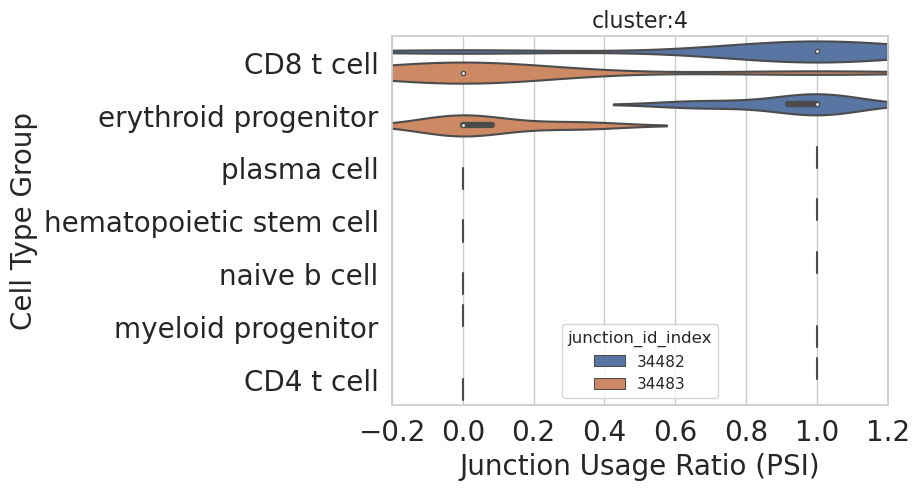

In [10]:
# let's visualize junction usage ratios for a given custer 
clust = 4
quick_clust_plot(clust, simple_data)

In [11]:
final_data

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id
0,0,393,36.0,36,0.0,1.000000,TSP11_BM_NA_SS2_B133711_B003959_Leukocyte_A10_...,monocyte,10_11165682_11217424,54626,ENSG00000048740.19
1,0,669,10.0,10,0.0,1.000000,TSP11_BM_NA_SS2_B133711_B003959_Leukocyte_A10_...,monocyte,10_121959410_121959500,57154,ENSG00000107672.15
2,0,1051,8.0,8,0.0,1.000000,TSP11_BM_NA_SS2_B133711_B003959_Leukocyte_A10_...,monocyte,10_17236379_17237229,54595,ENSG00000026025.16
3,0,2256,21.0,21,0.0,1.000000,TSP11_BM_NA_SS2_B133711_B003959_Leukocyte_A10_...,monocyte,10_72216138_72220053,56131,ENSG00000166295.9
4,0,2488,8.0,23,15.0,0.347826,TSP11_BM_NA_SS2_B133711_B003959_Leukocyte_A10_...,monocyte,10_7802854_7806973,55955,ENSG00000165629.20
...,...,...,...,...,...,...,...,...,...,...,...
10300997,2282,75803,0.0,355,355.0,0.000000,TSP2_BM_vertebralbody_SS2_B113709_B134460_Immu...,CD8 t cell,Y_2723364_2738199,112254,ENSG00000002586.20_PAR_Y
10300998,2282,75804,0.0,355,355.0,0.000000,TSP2_BM_vertebralbody_SS2_B113709_B134460_Immu...,CD8 t cell,Y_2723364_2738202,112254,ENSG00000002586.20_PAR_Y
10300999,2282,75805,0.0,355,355.0,0.000000,TSP2_BM_vertebralbody_SS2_B113709_B134460_Immu...,CD8 t cell,Y_2726373_2733356,112254,ENSG00000002586.20_PAR_Y
10301000,2282,75807,0.0,355,355.0,0.000000,TSP2_BM_vertebralbody_SS2_B113709_B134460_Immu...,CD8 t cell,Y_2726373_2738202,112254,ENSG00000002586.20_PAR_Y


In [12]:
C=len(final_data["cell_id_index"].unique())
J=len(final_data["junction_id_index"].unique())
C,J

(2283, 75851)

In [13]:
torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
  N,P = y.shape

  # total_counts should be of shape N,P cells by junctions

  # pyro.sample declares random variables (first arguement is the name assigned to it)
  # can also encode dependencies in these random variables such as
  # # Define another random variable 'y' dependent on 'x'
  # y = pyro.sample("y", dist.Normal(x, 1))

  a = pyro.sample("a", dist.Gamma(1.,1.).expand([P]).to_event(1))#.to('cuda') # per junction to model average behaviour
  b = pyro.sample("b", dist.Gamma(1.,1.).expand([P]).to_event(1))#.to('cuda')

  psi_dist = dist.Beta(a,b).expand([K,P]).to_event(2)
  #psi_dist = dist.Beta(1.,1.).expand([K,P]).to_event(2)  # simpler non-hierarchical version
  psi = pyro.sample("psi", psi_dist)#.to('cuda')

  pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K)/K))#.to('cuda')
  conc = pyro.sample("conc", dist.Gamma(1,1))#.to('cuda')

  # In Pyro, pyro.plate is used to declare that a set of sample statements are
  # conditionally independent given a particular dimension or plate. It helps
  #Pyro to perform efficient inference by taking advantage of this conditional independence.

  with pyro.plate('data1', N):
    # So, for each cell (i.e., for each value of the plate dimension),
    # you independently sample from the assign_dist, which is a Dirichlet
    # distribution parameterized by pi * conc. This allows each cell to have
    #its own distribution over cell states, and the assignments of cell states
    #to cells are considered independent of each other.
    assign_dist = dist.Dirichlet(pi * conc)
    # assign_dist = dist.Dirichlet(torch.ones(K)) # simpler non-hierarchical version
    assign = pyro.sample("assign", assign_dist)#.to('cuda')

  # so assign is N,K
  # and psi is K,P
  # even with masking below this step would still take a bunch of time 
  # calculating for all N and J
  pred = torch.mm(assign, psi)#.to('cuda') # -> dim N by J 

  # maybe try https://pytorch.org/docs/stable/generated/torch.einsum.html here for this operation above ? 
  # make sure that you can do backprop through them 

  total_counts = total_counts.to('cuda')
  y = y.to('cuda')

  # so pred is N, P which is inferred PSI of each junction for each cell depending on which assign factor it belongs to
  # Each element in pred row (along N) corresponds to the PSI value for a specific junction or event in that cell.
  #with pyro.plate('dims', P): # This outer plate indicates that the dimensions (junctions) are independent of each other across all data points (cells).
  #  with pyro.plate('data', N): #This inner plate indicates that the cells are independent of each other. Within each cell, you have multiple junctions (dimensions), and the inner plate makes it clear that you're modeling each cell's data independently.
  #    obs = pyro.sample('obs', dist.Binomial(total_counts, pred), obs=y)#.to('cuda')
  #    # try using our own dist.Binomial custom function, any entry where the count is zero would return 0 and ignore the normalization term 

  #print(assign.shape)
  #print(y.shape)
  #print(obs.shape)
  # Create a mask where y and total_counts are not -1
  mask_na = (total_counts != 654321)
  with pyro.plate('dims', P):
    with pyro.plate('data', N):
        obs = pyro.sample('obs', dist.Binomial(total_counts, pred, mask_na, obs=y))
        
def fit(y, total_counts, K, guide):
  adam = pyro.optim.Adam({"lr": 0.05})
  svi = SVI(model, guide, adam, loss=Trace_ELBO())
  pyro.clear_param_store()
  losses = []
  time_per_iter = []
  for j in range(100):
      print(j)
      loss = svi.step(y, total_counts, K)
      print(loss)
      losses.append(loss)
  return losses

In [14]:
def get_posterior_stats(
    model,
    guide,
    data,
    num_samples=100
):

    """ extract posterior samples (somewhat weirdly this is done with `Predictive`) """
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples)

    samples = predictive(*data) ## get posterior samples
    posterior_stats = { k : {
                "mean": torch.mean(v, 0),
                "std": torch.std(v, 0),
                "5%": v.kthvalue(int(len(v) * 0.05), dim=0)[0],
                "95%": v.kthvalue(int(len(v) * 0.95), dim=0)[0],
            } for k, v in samples.items() }

    return posterior_stats

In [15]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [16]:
y_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  2282,  2282,  2282],
                       [  393,   669,  1051,  ..., 75805, 75807, 75808]]),
       values=tensor([36., 10.,  8.,  ...,  0.,  0.,  0.]),
       size=(2283, 75851), nnz=10301002, layout=torch.sparse_coo)

In [ ]:
y = final_data[["cell_id_index", "junction_id_index", "junc_count"]]
# Pivot the DataFrame to create a matrix with rows as cell IDs and columns as junction IDs
y = y.pivot(index="cell_id_index", columns="junction_id_index", values="junc_count")
# Replace missing values (NaN) with 0
y = y.fillna(654.99)

In [ ]:
# Convert the DataFrame to a NumPy array and then to a PyTorch tensor
y_tensor = torch.tensor(y.to_numpy())

In [ ]:
# Convert the DataFrame to a sparse tensor directly without pivoting
# Assuming 'cell_id_index' and 'junction_id_index' are 0-based indices
indices_counts = torch.tensor(total_counts[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(total_counts['cluster_count'].to_numpy(), dtype=torch.float)

# Determine the size of the tensor
num_cells_counts = total_counts['cell_id_index'].max() + 1
num_junctions_counts = total_counts['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)

# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [ ]:
total_counts = final_data[["cell_id_index", "junction_id_index", "cluster_count"]]
# Pivot the DataFrame to create a matrix with rows as cell IDs and columns as junction IDs
total_counts = total_counts.pivot(index="cell_id_index", columns="junction_id_index", values="cluster_count")
# Replace missing values (NaN) with 0
total_counts = total_counts.fillna(654321)
# Convert the DataFrame to a NumPy array and then to a PyTorch tensor
total_counts_tensor = torch.tensor(total_counts.to_numpy(), dtype=torch.float32)

In [ ]:
K = 2 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

guide = AutoDiagonalNormal(model)
print(guide)

In [ ]:
losses = fit(y_tensor, total_counts_tensor, K, guide)
plt.plot(losses, label = "Diagonal variational posterior")

In [ ]:
ps = get_posterior_stats(model, guide, data = [y_tensor, total_counts_tensor, K])

In [ ]:
ps["pi"]["mean"]

In [ ]:
ps["conc"]

In [ ]:
# can we plot assign probabilityies for each cell
assign_post = ps["assign"]["mean"]
# convert to 2d from 3d dont need first dimension
assign_post = assign_post[0,:,:]
# plot N cells by K factors but just frist two factors scatter plot
assign_post

In [ ]:
cell_ids_conversion

In [ ]:
# color point by cell_ids_conversion["cell_type"] and reduce point size and alpha
sns.scatterplot(x=assign_post[:,0], y=assign_post[:,1], hue=cell_ids_conversion["cell_type"], s=10, alpha=0.5)

In [ ]:
# do the K factors capture the simulated cell types?
# plot clustermap N by K from assign_post
sns.clustermap(assign_post, cmap="Blues")

In [ ]:
plt.hist(ps["assign"]["mean"].numpy().flatten())
plt.show()